# 06 - Final project story: data, model, and GIS outputs

This read-only notebook presents the completed capstone from data design through final temporal model evidence and GIS context. It uses only validated project artefacts. It does not fit a model, calculate a new score, rewrite an image, create a forecast, or make a purchase recommendation.

The spatial context figures describe **1 km mainland grid cells with fire recurrence measured in a 2 km context**.

In [38]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print('Repository root resolved; all paths below are repository-relative.')

Repository root resolved; all paths below are repository-relative.


## 1. Project design and evidence contract

The model estimates continuous next-year burned share from predictor-year information only. The final temporal test remains separate from model selection.

In [39]:
from src.feature_contract import FIELD_CONTRACTS, PREDICTOR_COLUMNS, TARGET_COLUMN
from src.final_visuals import validate_final_visuals
from src.model_diagnostics import validate_model_diagnostics

national_validation_path = PROJECT_ROOT / 'data/processed/national_panel_2015_2024_validation.json'
eda_path = PROJECT_ROOT / 'reports/validation/national_panel_model_readiness_eda.json'
final_metrics_path = PROJECT_ROOT / 'data/processed/extended_model_selection_2010_2021/final_temporal_test_metrics.json'
national_validation = json.loads(national_validation_path.read_text(encoding='utf-8'))
eda = json.loads(eda_path.read_text(encoding='utf-8'))
final_metrics = json.loads(final_metrics_path.read_text(encoding='utf-8'))
presentation_validation = validate_final_visuals()
diagnostic_inventory = validate_model_diagnostics()

assert len(PREDICTOR_COLUMNS) == 9
assert national_validation['actual_row_count'] == 891_120
assert tuple(final_metrics['design']['final_test_years']) == (2022, 2023, 2024)
assert diagnostic_inventory['status'] == 'verified_existing'

design = pd.DataFrame([
    ('Spatial unit', 'One EPSG:3763 mainland Portugal 1 km cell per predictor year'),
    ('Panel', f"{national_validation['grid_cell_count']:,} cells; {national_validation['actual_row_count']:,} cell-year rows for T=2015-2024"),
    ('Predictors', f"{len(PREDICTOR_COLUMNS)} leakage-safe predictors"),
    ('Target', 'Continuous burned_share_next_year in T+1'),
    ('Frozen model training', 'T=2010-2019'),
    ('Model validation', 'T=2020-2021'),
    ('Final temporal test', 'T=2022-2024; outcomes 2023-2025'),
], columns=['Item', 'Validated design'])
display(design)

,Item,Validated design
0,Spatial unit,One EPSG:3763 mainland Portugal 1 km cell per ...
1,Panel,"89,112 cells; 891,120 cell-year rows for T=201..."
2,Predictors,9 leakage-safe predictors
3,Target,Continuous burned_share_next_year in T+1
4,Frozen model training,T=2010-2019
5,Model validation,T=2020-2021
6,Final temporal test,T=2022-2024; outcomes 2023-2025


## 2. Nine-predictor data-science contract

All nine predictors are present in the final model in this exact order. Each row answers three questions: what the variable measures, why it may be relevant to burned-area exposure, and which information was allowed at prediction time. The source-year rule makes the temporal boundary auditable: predictors use information from T or earlier, while the target is observed only in T+1.

The 2 km suffix does not create a second analytical grid. It means that the 1 km cell is evaluated together with an outward 2 km context buffer. The two monthly-extreme features are summaries of the same T-only JJAS ERA5-Land inputs, not future information.

| ERA5-Land 2m_temperature means air temperature at a standard height of 2 metres above the land surface. The 2m label describes measurement height, not spatial resolution or a context buffer.

**Feature meanings**

| Predictor | Plain-language meaning |
|---|---|
| `built_up_share` | Proportion of the cell's land area classified as built-up in the governed CLC layer; built-environment context. |
| `forest_shrub_share_2km` | Proportion of mainland land in the cell and outward 2 km context classified as forest or shrub; fuel and landscape context. |
| `mean_slope_2km` | Average terrain slope in the mainland-masked 2 km context from Copernicus DEM GLO-30; topographic context. |
| `fire_years_previous_10y_2km` | Number of distinct fire years from T-10 through T-1 within the 2 km context; historical fire recurrence. |
| `warm_season_mean_2m_temperature_c` | Mean June-September air temperature at 2 metres above the land surface in predictor year T; 2 m is a measurement height, not spatial resolution. |
| `warm_season_total_precipitation_mm` | Day-weighted June-September precipitation total in T; warm-season moisture availability. |
| `warm_season_mean_soil_water_layer1` | Mean June-September volumetric soil-water content in ERA5-Land layer 1 during T; average warm-season soil moisture. |
| `warm_season_max_monthly_2m_temperature_c` | Highest monthly mean June-September air temperature at 2 metres above the land surface during T; warm-season heat extreme. |
| `warm_season_min_monthly_soil_water_layer1` | Lowest monthly mean June-September layer-1 soil-water value during T; warm-season dryness extreme. |

In [40]:
feature_roles = {
    'built_up_share': 'Built environment context',
    'forest_shrub_share_2km': 'Fuel and landscape context',
    'mean_slope_2km': 'Topographic context',
    'fire_years_previous_10y_2km': 'Historical fire recurrence',
    'warm_season_mean_2m_temperature_c': 'Warm-season climate',
    'warm_season_total_precipitation_mm': 'Warm-season climate',
    'warm_season_mean_soil_water_layer1': 'Warm-season climate',
    'warm_season_max_monthly_2m_temperature_c': 'Warm-season climate extreme',
    'warm_season_min_monthly_soil_water_layer1': 'Warm-season climate extreme',
}
feature_contract = pd.DataFrame([
    {
        'Predictor': name,
        'Modelling role': feature_roles[name],
        'Unit': FIELD_CONTRACTS[name].unit,
        'Allowed range': f"{FIELD_CONTRACTS[name].minimum} to {FIELD_CONTRACTS[name].maximum}",
        'Temporal/source rule': FIELD_CONTRACTS[name].source_year_rule,
    }
    for name in PREDICTOR_COLUMNS
])
display(feature_contract)
print('Target:', TARGET_COLUMN)

,Predictor,Modelling role,Unit,Allowed range,Temporal/source rule
0,built_up_share,Built environment context,share_of_cell_land_area,0.0 to 1.0,governed CLC reference year assigned to T
1,forest_shrub_share_2km,Fuel and landscape context,share_of_mainland_land_in_2km_outward_buffer,0.0 to 1.0,governed CLC reference year assigned to T
2,mean_slope_2km,Topographic context,degrees,0.0 to 90.0,static Copernicus DEM GLO-30 2021 release
3,fire_years_previous_10y_2km,Historical fire recurrence,count_of_distinct_years,0.0 to 10.0,inclusive T-10 through T-1
4,warm_season_mean_2m_temperature_c,Warm-season climate,degrees_Celsius,-20.0 to 60.0,JJAS of T only; ERA5-Land air temperature at 2...
5,warm_season_total_precipitation_mm,Warm-season climate,millimetres_JJAS_total,0.0 to 3000.0,day-weighted JJAS of T only
6,warm_season_mean_soil_water_layer1,Warm-season climate,m3_per_m3,0.0 to 1.0,JJAS of T only
7,warm_season_max_monthly_2m_temperature_c,Warm-season climate extreme,degrees_Celsius,-20.0 to 60.0,maximum of monthly-mean June-September air tem...
8,warm_season_min_monthly_soil_water_layer1,Warm-season climate extreme,m3_per_m3,0.0 to 1.0,minimum of monthly-mean June-September layer-1...


Target: burned_share_next_year


## 3. What the data shows before modelling

The next-year burned-share target is strongly zero-heavy: in most years, the large majority of 1 km cells have no recorded burned area in the following year. A model could therefore appear accurate by predicting very small values for nearly every cell. For that reason, we assess overall regression error together with error among cells that burned and a technical ranking diagnostic. 

The correlation matrix checks how the nine input features vary together. The strongest correlations occur between related climate summaries, such as average and maximum summer temperature, or average and minimum summer soil water. These relationships are expected and show partial overlap, not a data error. Correlation is not evidence of causation and does not by itself determine which features the model uses most.  

Together, these checks justify a two-part hurdle regression: one component estimates whether any burning is likely, and the other estimates the expected burned share where burning occurs.

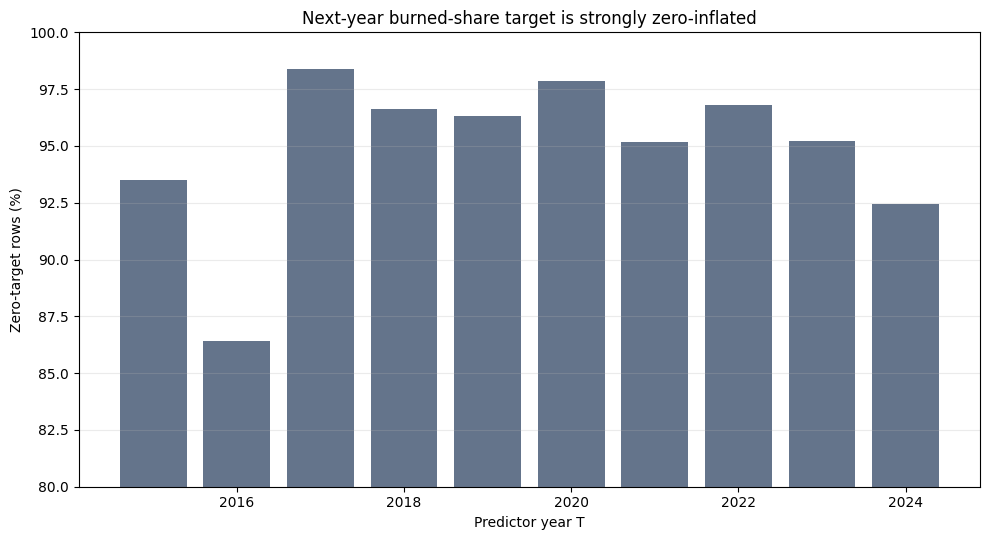

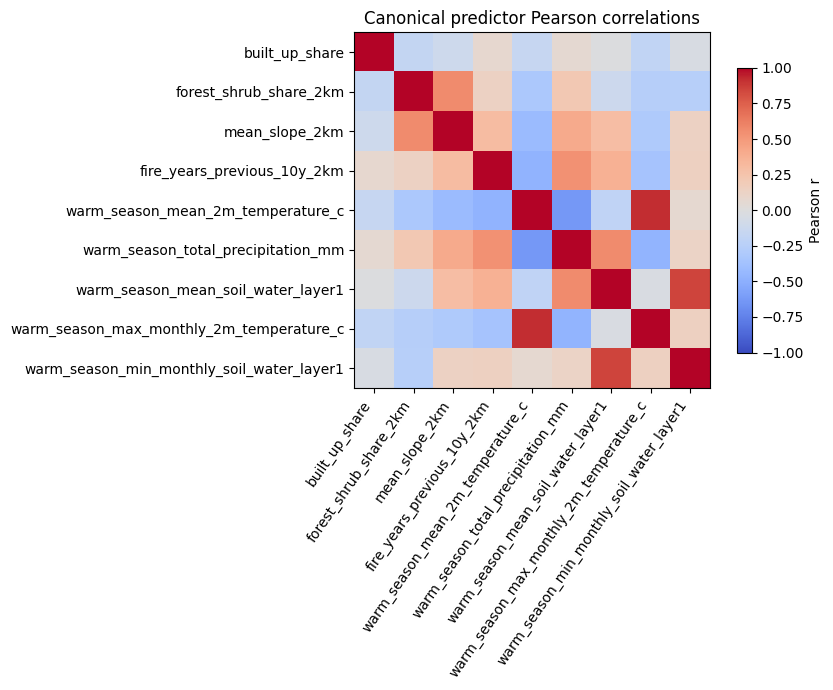

Live EDA mode: used validated EDA summaries only; no panel, report, or PNG file was changed.
Overall zero-target proportion: 94.87%


In [41]:
# Default: render charts live from the validated EDA JSON. This reads no raw data,
# does not load the full national panel, and does not overwrite the exported PNGs.
SHOW_LIVE_EDA_DIAGNOSTICS = True

eda_figures = {
    'Target distribution by predictor year': 'reports/figures/panel_eda_target_by_year.png',
    'Predictor correlation matrix': 'reports/figures/panel_eda_predictor_correlations.png',
}

if SHOW_LIVE_EDA_DIAGNOSTICS:
    import matplotlib.pyplot as plt

    from src.feature_contract import PREDICTOR_COLUMNS

    target_by_year = pd.DataFrame.from_dict(eda['target']['by_year'], orient='index').sort_index()
    target_by_year.index = target_by_year.index.astype(int)
    target_by_year = target_by_year.sort_index()
    fig, axis = plt.subplots(figsize=(10, 5.5))
    axis.bar(target_by_year.index, target_by_year['zero_proportion'] * 100, color='#64748b')
    axis.set(
        ylabel='Zero-target rows (%)',
        xlabel='Predictor year T',
        title='Next-year burned-share target is strongly zero-inflated',
        ylim=(80, 100),
    )
    axis.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    display(fig)
    plt.close(fig)

    correlations = pd.DataFrame(eda['correlations']).loc[list(PREDICTOR_COLUMNS), list(PREDICTOR_COLUMNS)]
    fig, axis = plt.subplots(figsize=(9, 7))
    image = axis.imshow(correlations.to_numpy(), vmin=-1, vmax=1, cmap='coolwarm')
    axis.set_xticks(range(len(correlations.columns)), correlations.columns, rotation=55, ha='right')
    axis.set_yticks(range(len(correlations.index)), correlations.index)
    fig.colorbar(image, ax=axis, label='Pearson r', shrink=0.8)
    axis.set_title('Canonical predictor Pearson correlations')
    fig.tight_layout()
    display(fig)
    plt.close(fig)
    print('Live EDA mode: used validated EDA summaries only; no panel, report, or PNG file was changed.')
else:
    for title, relative_path in eda_figures.items():
        path = PROJECT_ROOT / relative_path
        assert path.is_file() and path.stat().st_size > 5_000
        print(title, '<-', relative_path)
        display(Image(filename=str(path), width=900))

print(f"Overall zero-target proportion: {eda['target']['overall_zero_proportion']:.2%}")

## 4. Final temporal model evidence

This is a one-time evaluation on the untouched final period: predictor years 2022-2024 and their following-year observed burned shares. It asks whether models selected before these years still give useful comparative estimates later in time. It is not training evidence, and it is not a buyer forecast or a safety assessment.

| Model | What it does | Why it is included |
| --- | --- | --- |
| Historical recurrence baseline | A transparent benchmark. It uses only `fire_years_previous_10y_2km` and learns, from the training period only, the average next-year burned share associated with each historical-fire count. It is a simple empirical lookup/mapping, not a library machine-learning algorithm. | Historical local fire recurrence is an important, easy-to-explain reference. A more complex method should improve on it before its additional complexity is trusted. |
| Nine-feature hurdle | A two-part regression: a `HistGradientBoostingClassifier` estimates whether any burning is likely, and a `HistGradientBoostingRegressor` estimates burned share when burning occurs. Their product is the estimated next-year burned share. It uses all nine approved predictors. | The target contains many exact zeros but some positive burned shares. Separating occurrence from positive magnitude is a reasonable way to represent that structure while keeping the final output continuous. |

### Why histogram gradient boosting was used

Histogram gradient boosting builds an ensemble of many small decision trees. Before splitting, it groups continuous values into bins, which makes fitting practical for a large tabular panel and lets the model represent non-linear relationships and interactions without assuming that, for example, a one-unit change in slope, fire history, temperature, or precipitation always has the same effect. This is relevant because wildfire exposure can depend on combinations of historical recurrence, landscape context, terrain, and climate.

The model uses deliberately constrained, deterministic settings and was selected through the pre-final training/validation process, not by searching the held-out 2022-2024 period. It is still an associative predictive model: it does not establish that any predictor causes wildfire.

Both outputs are **estimated burned shares**, not probabilities. Neither model says whether a property is safe, whether someone should buy it, or what will happen at one address.

### How to read the two result tables

The first table combines every held-out cell-year from 2022-2024, giving one overall comparison. The second table splits the same evidence by predictor year, so it shows whether a result is stable or is driven by only one fire season.

| Measure | Plain-language meaning | Better direction |
| --- | --- | --- |
| MAE | Average absolute difference between the estimated and observed burned share across all cells. | Lower |
| RMSE | Similar to MAE, but large mistakes count more heavily. It exposes whether rare large-fire errors remain. | Lower |
| Positive-row MAE | Average absolute error only among cells that actually burned. It prevents a model from looking good merely because most cells did not burn. | Lower |
| Capture@20% | Rank cells by estimated burned share, take the highest-scoring 20% of cells, then measure the share of cells that actually burned that fall inside that set. It is a technical ranking diagnostic: higher means the model concentrates more burning cells near the top of its ranking. | Higher |

Capture@20% is **not** a buyer threshold and does not need to be shown to a location searcher. It helps the project test whether a model can narrow a large map into a smaller area for comparative investigation. A buyer-facing map can use the continuous estimated burned share and historical context without exposing a 20% cutoff.

In [42]:
overall_metrics_path = PROJECT_ROOT / diagnostic_inventory['tables']['overall_metrics']
by_year_metrics_path = PROJECT_ROOT / diagnostic_inventory['tables']['by_year_metrics']
overall_metrics = pd.read_csv(overall_metrics_path)
by_year_metrics = pd.read_csv(by_year_metrics_path)
model_labels = {
    'historical_recurrence_baseline': 'Historical recurrence baseline',
    'nine_feature_hurdle': 'Nine-feature hurdle',
}
for frame in (overall_metrics, by_year_metrics):
    frame['model'] = frame['model'].map(model_labels).fillna(frame['model'])

display(overall_metrics[['model', 'MAE', 'RMSE', 'positive_row_MAE', 'capture_at_20_percent']])
display(by_year_metrics[['predictor_year', 'model', 'MAE', 'RMSE', 'positive_row_MAE', 'capture_at_20_percent']])

baseline = overall_metrics.set_index('model').loc['Historical recurrence baseline']
hurdle = overall_metrics.set_index('model').loc['Nine-feature hurdle']
mae_change = (baseline['MAE'] - hurdle['MAE']) / baseline['MAE'] * 100
capture_change = (hurdle['capture_at_20_percent'] - baseline['capture_at_20_percent']) * 100
print(
    f"Overall reading: the nine-feature hurdle reduced all-row MAE by {mae_change:.1f}% and increased Capture@20% by {capture_change:.1f} percentage points. "
    'However, its RMSE and positive-row MAE are effectively tied to or slightly worse than the baseline. '
    'Scientifically, this supports a modest improvement for comparative screening, while showing that large fires and the size of positive burned shares remain difficult to estimate. '
    'It is not evidence of property-level or safety-prediction accuracy.'
)

,model,MAE,RMSE,positive_row_MAE,capture_at_20_percent
0,Historical recurrence baseline,0.029186,0.110595,0.310359,0.482014
1,Nine-feature hurdle,0.021401,0.110697,0.313181,0.500361


,predictor_year,model,MAE,RMSE,positive_row_MAE,capture_at_20_percent
0,2022,Historical recurrence baseline,0.017313,0.047503,0.114014,0.566350
1,2022,Nine-feature hurdle,0.008225,0.045963,0.114729,0.492080
2,2023,Historical recurrence baseline,0.028027,0.105194,0.312945,0.614534
3,2023,Nine-feature hurdle,0.020792,0.105482,0.316560,0.546096
4,2024,Historical recurrence baseline,0.042219,0.152876,0.391356,0.379499
5,2024,Nine-feature hurdle,0.035186,0.153371,0.394567,0.448822


Overall reading: the nine-feature hurdle reduced all-row MAE by 26.7% and increased Capture@20% by 1.8 percentage points. However, its RMSE and positive-row MAE are effectively tied to or slightly worse than the baseline. Scientifically, this supports a modest improvement for comparative screening, while showing that large fires and the size of positive burned shares remain difficult to estimate. It is not evidence of property-level or safety-prediction accuracy.


### What the final-test diagnostic figures show

Each figure is built from the saved, row-level final-test predictions and observed burned shares. No model is fitted, tuned, or scored again when this notebook is run in its normal mode.

| Figure | How it was built | What story it tells |
| --- | --- | --- |
| `model_final_test_metric_comparison.png` | Three bars compare the two models over all final-test rows: all-row MAE, all-row RMSE, and Capture@20%. | Whether the nine-feature hurdle improves typical error and ranking versus the transparent baseline, while making clear if rare large errors remain. |
| `model_final_test_observed_vs_estimated.png` | Saved observed and estimated shares are plotted cell-year by cell-year. The equality line marks perfect estimates; the panel also separates positive-target cells and shows residuals by year. | Whether estimates broadly follow observed burned share, whether positive burns are underestimated or overestimated, and whether errors differ across the three later years. Dense clusters near zero are expected because most cell-years did not burn. |
| `model_final_test_binned_observed_vs_estimated.png` | Rows are ordered by the saved nine-feature estimate and split into up to ten equal-sized estimate bins. Each bin compares mean estimated share with mean observed share. | Whether higher estimated-share groups also have higher observed burned share, and whether the model systematically over- or under-estimates magnitude. It is a regression diagnostic, not probability calibration. |

Together, the tables and figures support a careful conclusion: the nine-feature hurdle is a modestly better comparative estimator on average than the recurrence-only benchmark, but it still misses difficult high-burn outcomes. That is useful model evidence, not a guarantee about any future location.

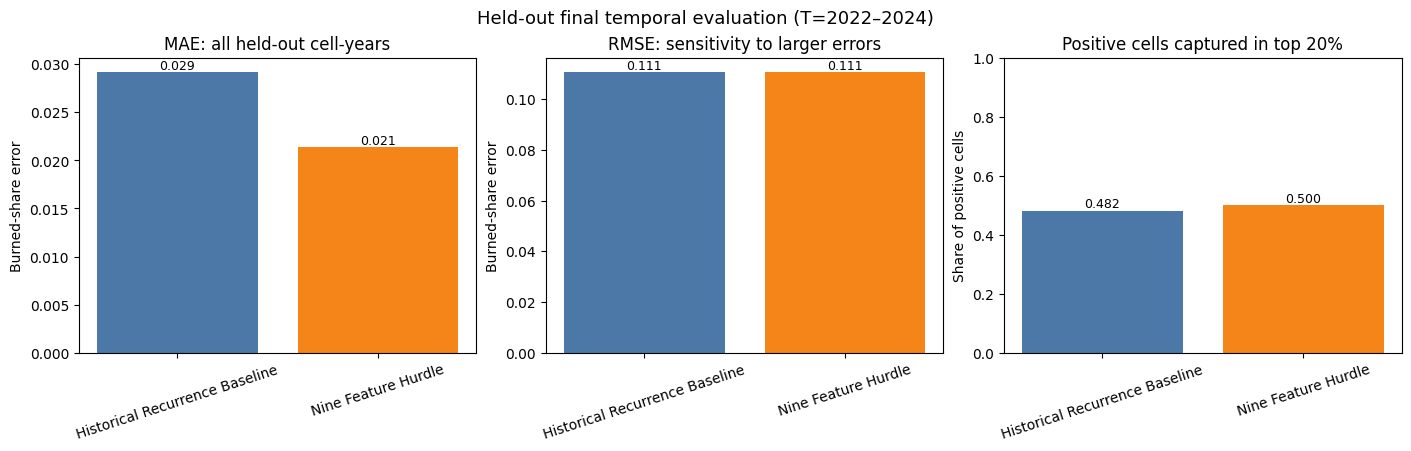

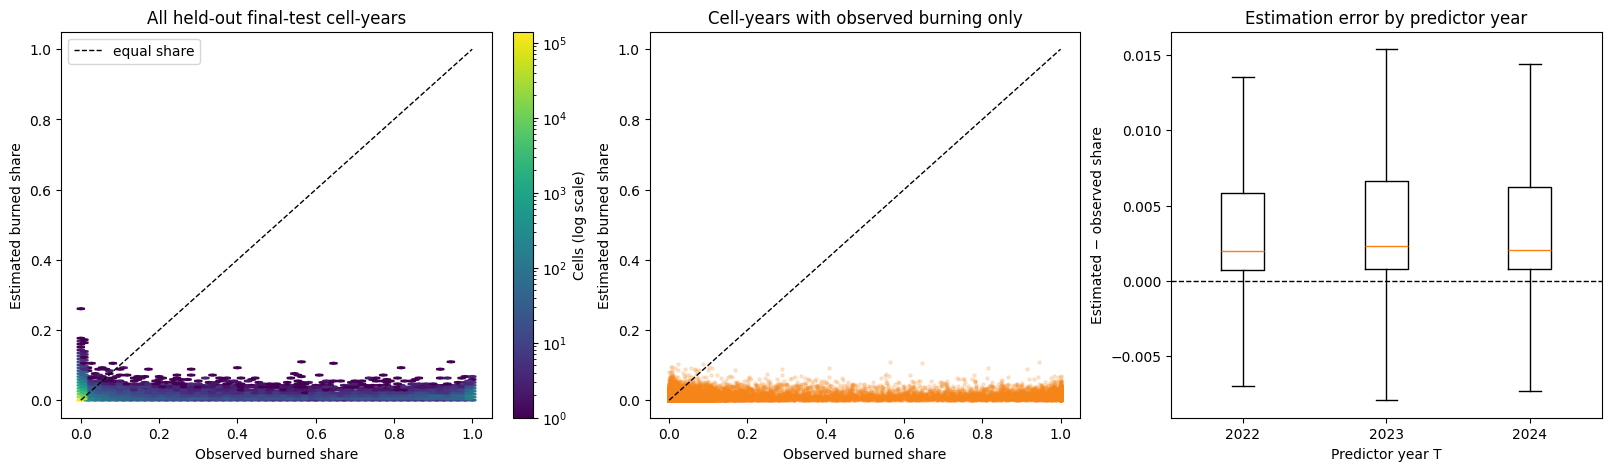

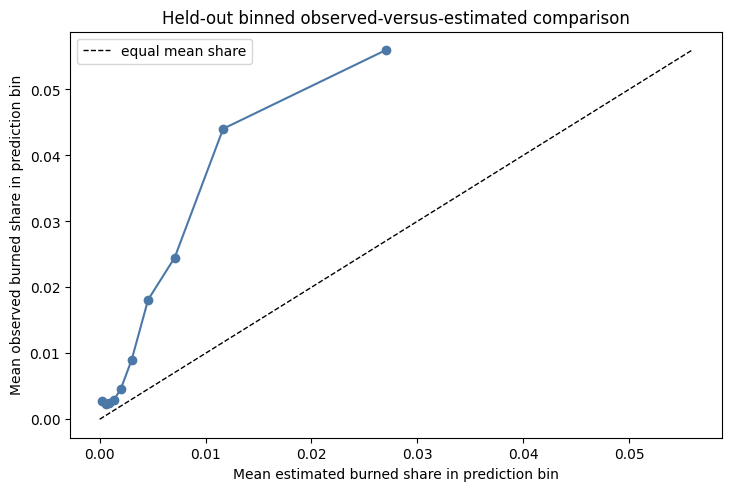

Live diagnostic mode: read saved final-test data only; no models or PNG files were changed.


In [43]:
from IPython.display import clear_output

# Replace prior gallery output when this cell is run again.
clear_output(wait=True)

# Default: display the validated PNGs. Set to True to recreate the diagnostic plots
# live from the saved final-test prediction table, without fitting models or writing files.
SHOW_LIVE_MODEL_DIAGNOSTICS = True

figure_order = [
    'metric_comparison',
    'prediction_diagnostics',
    'binned_comparison',
]

if SHOW_LIVE_MODEL_DIAGNOSTICS:
    import matplotlib.pyplot as plt

    from src.notebook_reporting import (
        binned_observed_estimated_table,
        plot_binned_observed_estimated,
        plot_metric_comparison,
        plot_prediction_diagnostics,
    )

    prediction_path = PROJECT_ROOT / 'data/processed/extended_model_selection_2010_2021/final_temporal_test_predictions.parquet'
    assert prediction_path.is_file(), prediction_path
    raw_metrics = pd.read_csv(overall_metrics_path)
    final_predictions = pd.read_parquet(prediction_path)
    figure = plot_metric_comparison(raw_metrics.set_index('model'))
    display(figure)
    plt.close(figure)
    figure = plot_prediction_diagnostics(final_predictions, model_column='nine_feature_hurdle')
    display(figure)
    plt.close(figure)
    live_bins = binned_observed_estimated_table(final_predictions, model_column='nine_feature_hurdle')
    figure = plot_binned_observed_estimated(live_bins)
    display(figure)
    plt.close(figure)
    print('Live diagnostic mode: read saved final-test data only; no models or PNG files were changed.')
else:
    for title in figure_order:
        relative_path = diagnostic_inventory['figures'][title]
        path = PROJECT_ROOT / relative_path
        assert path.is_file() and path.stat().st_size > 5_000
        print(title.replace('_', ' ').title(), '<-', relative_path)
        display(Image(filename=str(path), width=900))

## 5. GIS outputs: historical evidence, official comparison, and a 2026 estimate

This section is deliberately separate from the next-year regression model. It examines an **observed historical evidence layer**: one 1 km mainland grid cell at a time, with fire recurrence measured in a mainland-masked 2 km outward context. It does not predict future fire, label a place safe, or make a purchase recommendation.

### What the historical-screening GeoPackage represents

`data/processed/spatial_outputs/historical_residential_wildfire_exposure_screening.gpkg`, layer `historical_exposure_screening`, is the reusable GIS evidence layer. It contains 89,112 EPSG:3763 mainland 1 km cells. For each cell, the pipeline counts the **distinct observed ICNF burned-area years from 2016 through 2025** that intersect its mainland-masked 2 km context. National empirical recurrence tertiles convert that count into transparent descriptive bands: lower = 0-1 years, moderate = 2-3 years, and higher = 4-10 years.

The same layer also joins generalized CLC 2018 landscape context, mean terrain slope, and the **predominant valid official ICNF structural-hazard class** from the 25 m 2020-2030 raster within each 1 km mainland cell. The official class is a separate statutory structural-hazard measure; it is not the target, a model prediction, or an accuracy label for the historical recurrence band.

### Reproducibility / runbook

The bounded, deterministic build is implemented in `src/historical_exposure_screening.py` and invoked by `scripts/build_historical_exposure_screening.py`. It uses annual dissolved ICNF geometry only for the completed 2016-2025 evidence window, reuses the canonical grid and mainland mask, assigns the 25 m official class by predominant valid pixel count, and writes the GeoPackage plus the three summary CSV tables used below. The portable QGIS project (`qgis/wildfire_exposure_screening_portugal.qgz`) presents the same validated GeoPackage interactively; it is not a separate analytical workflow.

### How to read the live maps, plot, and tables

The first map shows where historical recurrence bands occur. The second map shows the official ICNF structural-hazard class summarized to the same 1 km cell. The third map shows the 2026 model estimate grouped into the same three presentation colours used in QGIS: lower percentile (0-50%), intermediate percentile (50-80%), and higher percentile (80-100%). Each legend is placed below its map panel and uses the corresponding QGIS captions; it does not cover the Portugal outline. The heatmap and cross-tab below count how often the first two descriptive systems co-occur. They are **not** an accuracy test: one is a ten-year observed-recurrence summary and the other is an official structural map created under a different methodology. Agreement and disagreement are both informative and expected.

### 2026 estimated comparative wildfire exposure — 1 km cells

`data/processed/spatial_outputs/estimated_comparative_wildfire_exposure_2026.gpkg`, layer `estimated_comparative_exposure_2026`, is a separate model-based GIS output. It applies the fixed nine-feature hurdle model to **2025 predictor inputs** and stores one continuous `predicted_burned_share_next_year` estimate for each of the same 89,112 mainland 1 km cells. To make the three-map figure readable, its panel groups the separate `predicted_exposure_percentile` field into lower (0-50%), intermediate (50-80%), and higher (80-100%) estimated comparative exposure. These presentation bands do not replace the continuous model estimate. They are not a probability that a property is safe, a recorded 2026 fire outcome, or a purchase recommendation.

There is no observed 2026 outcome yet, so this layer cannot yet have a 2026 error score. It is intended for broad comparative location research: a user can inspect relative model estimates alongside the separate 2016-2025 observed-recurrence and official structural-hazard layers. The portable QGIS project `qgis/wildfire_exposure_screening_portugal_2026.qgz` presents the same scored layer interactively; it is a presentation view, not a separate scoring workflow.

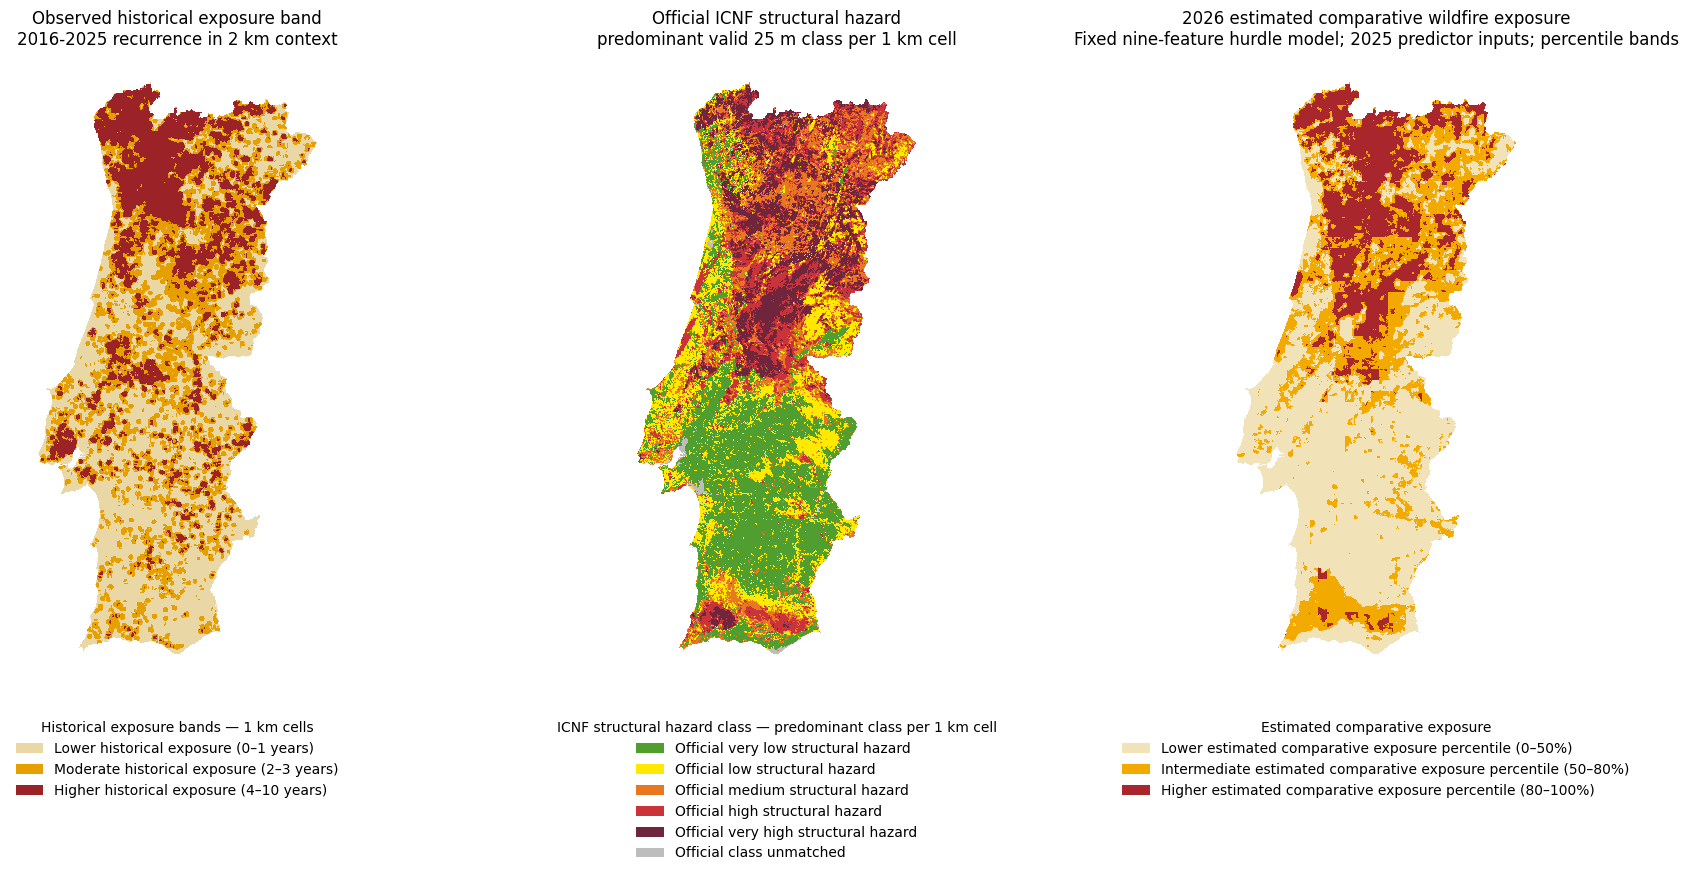

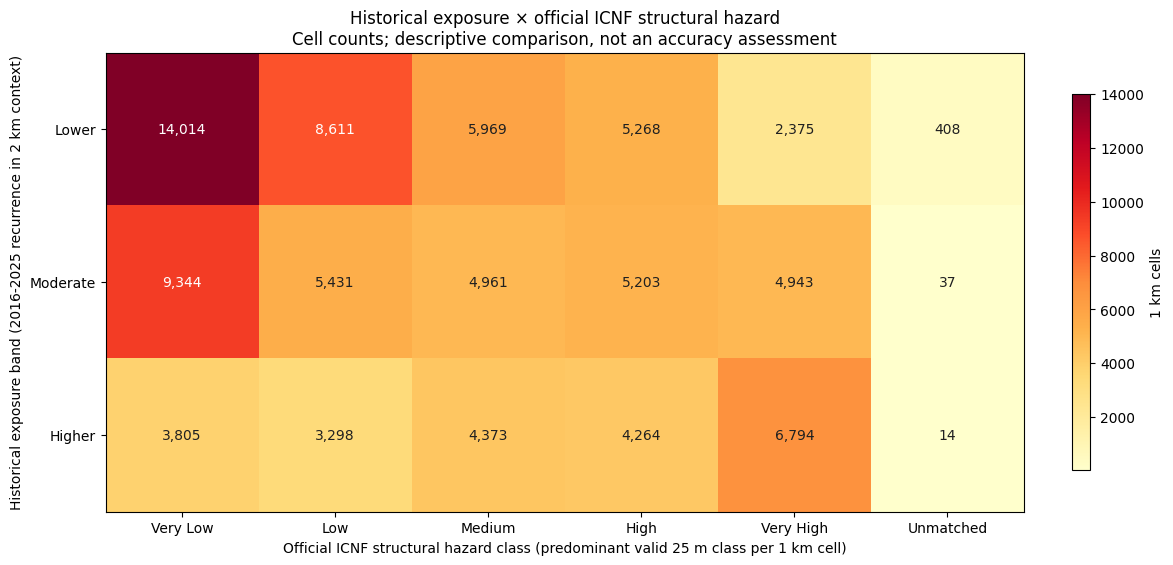

Historical exposure-band distribution


,historical_exposure_band,cell_count,share_of_cells
0,lower,36645,41.12%
1,moderate,29919,33.57%
2,higher,22548,25.30%


Official ICNF structural-hazard distribution


,official_icnf_hazard_class,cell_count,share_of_cells
0,very_low,27163,30.48%
1,low,17340,19.46%
2,medium,15303,17.17%
3,high,14735,16.54%
4,very_high,14112,15.84%
5,unmatched,459,0.52%


Historical exposure band by official ICNF structural-hazard class (1 km cell counts)


official_icnf_hazard_class,very_low,low,medium,high,very_high,unmatched
historical_exposure_band,,,,,,
lower,14014,8611,5969,5268,2375,408
moderate,9344,5431,4961,5203,4943,37
higher,3805,3298,4373,4264,6794,14


In [44]:
import importlib

import matplotlib.pyplot as plt
import src.historical_screening_reporting as historical_reporting
import src.operational_forecast_reporting as operational_reporting

# Reload reporting helpers so this cell also works after source-code edits in an existing kernel.
historical_reporting = importlib.reload(historical_reporting)
operational_reporting = importlib.reload(operational_reporting)

from src.historical_screening_reporting import (
    historical_screening_display_tables,
    load_historical_screening_artifacts,
    plot_historical_and_icnf_maps,
    plot_historical_icnf_crosstab,
)
from src.operational_forecast_reporting import load_operational_forecast_spatial_artifact

historical_artifacts = load_historical_screening_artifacts(PROJECT_ROOT)
operational_estimate = load_operational_forecast_spatial_artifact(PROJECT_ROOT, forecast_year=2026)

figure = plot_historical_and_icnf_maps(historical_artifacts.screening, operational_estimate.scores)
display(figure)
plt.close(figure)

figure = plot_historical_icnf_crosstab(historical_artifacts.cross_matrix)
display(figure)
plt.close(figure)

band_summary, hazard_summary, cross_matrix = historical_screening_display_tables(historical_artifacts)
print('Historical exposure-band distribution')
display(band_summary)
print('Official ICNF structural-hazard distribution')
display(hazard_summary)
print('Historical exposure band by official ICNF structural-hazard class (1 km cell counts)')
display(cross_matrix)

## 6. Correct use, limitations, and reproducibility

The final map and model evidence support broad-area comparative research only. They are not a next-year forecast guarantee, a property-level safety assessment, or a purchase recommendation.

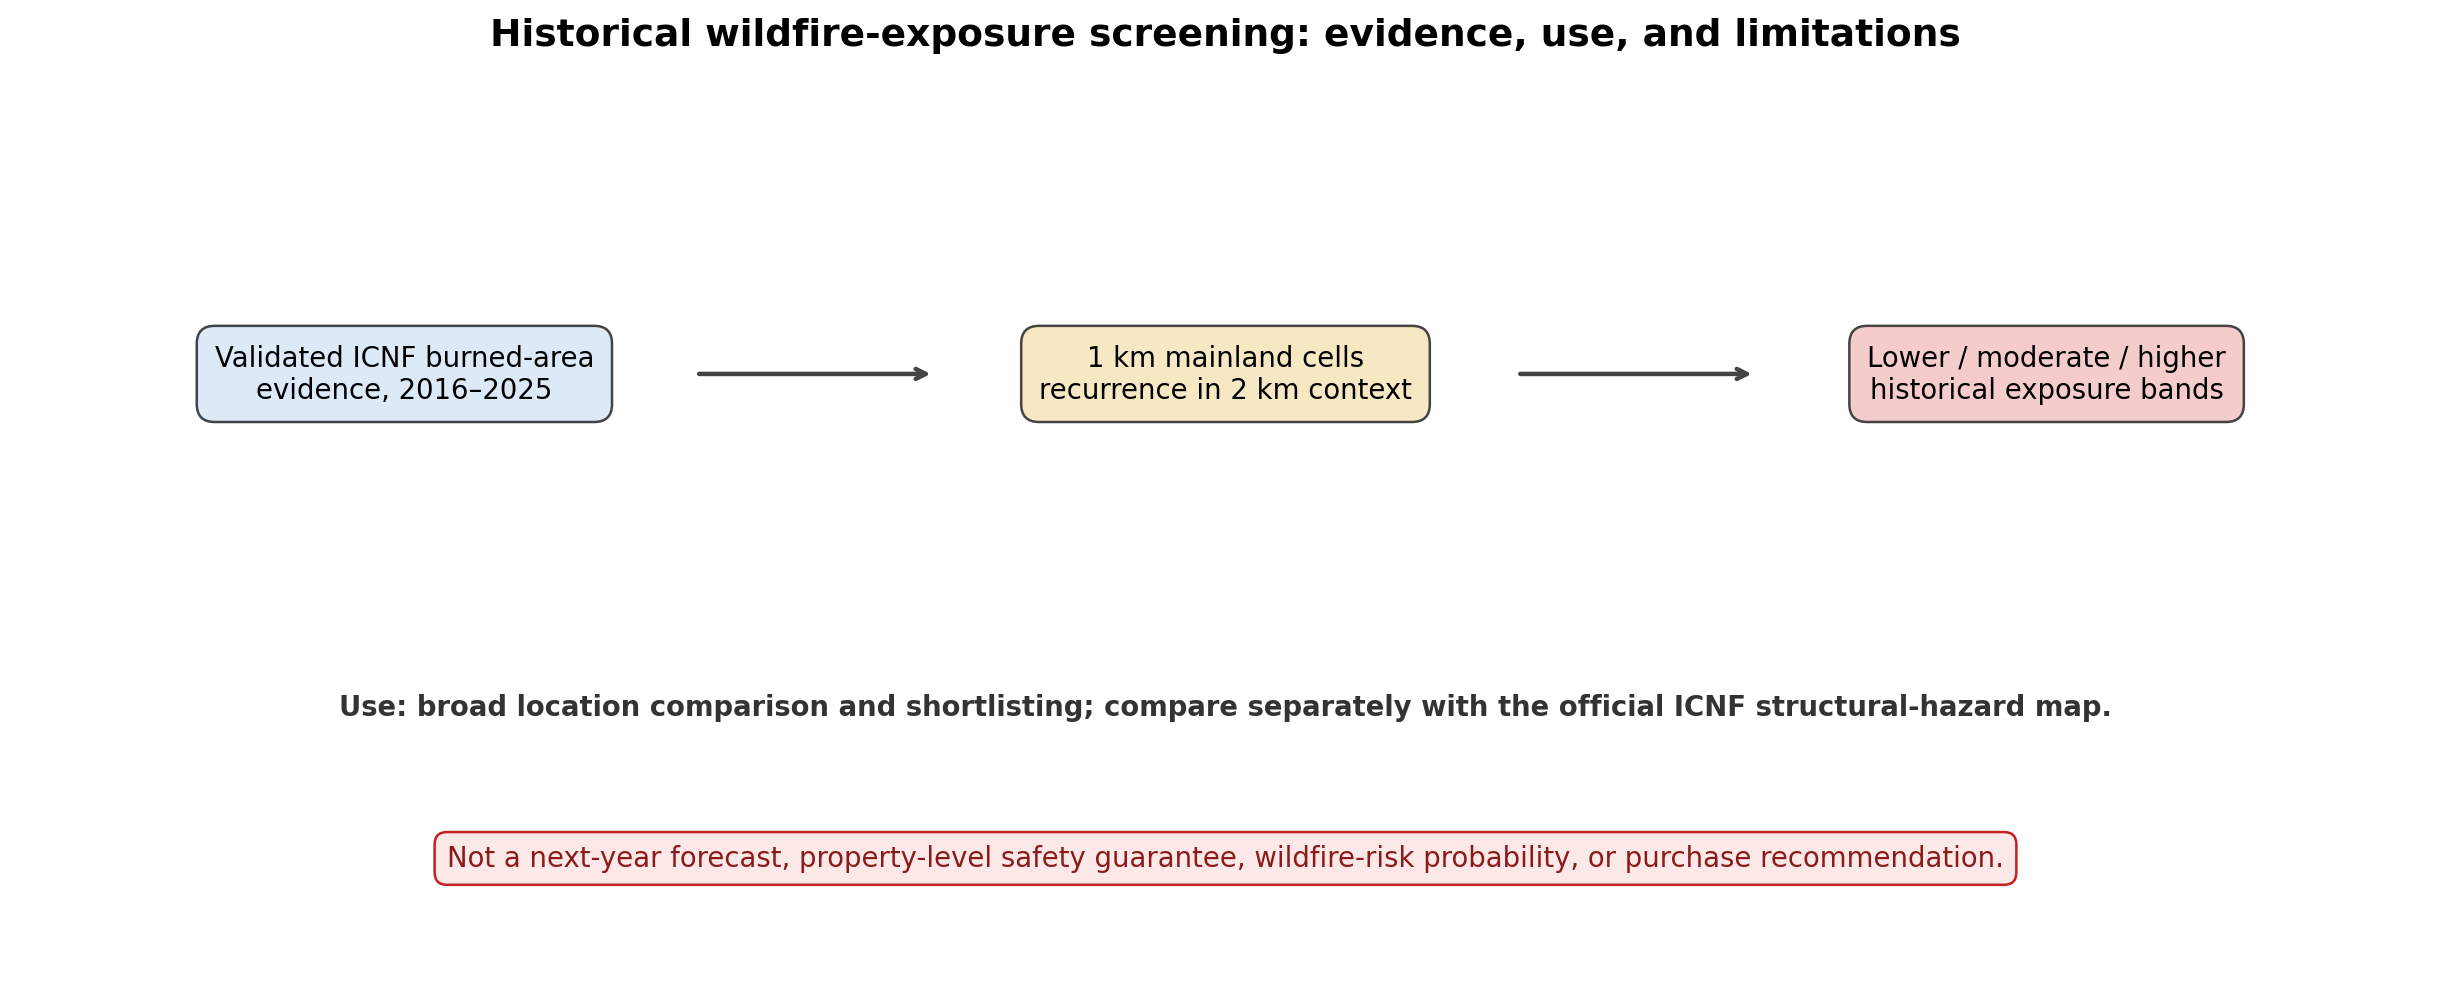

QGIS project: qgis/wildfire_exposure_screening_portugal.qgz
Historical screening GeoPackage: data/processed/spatial_outputs/historical_residential_wildfire_exposure_screening.gpkg
Full reproducible rebuild: python scripts/run_project.py --mode reproduce --confirm-rebuild


In [45]:
record = presentation_validation['figures']['decision_limitations']
path = PROJECT_ROOT / record['path']
assert record['status'] == 'verified_existing' and path.is_file()
display(Image(filename=str(path), width=900))

print('QGIS project: qgis/wildfire_exposure_screening_portugal.qgz')
print('Historical screening GeoPackage: data/processed/spatial_outputs/historical_residential_wildfire_exposure_screening.gpkg')
print('Full reproducible rebuild: python scripts/run_project.py --mode reproduce --confirm-rebuild')